<a href="https://colab.research.google.com/github/AmanuelDaget/YOLOv12-Object-Recognition-from-Remote-Sensing-images/blob/main/YOLOv12_Object_Recognition_from_Remote_Sensing_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object Recognition using YOLOv12 from Remote Sensing images**

**Install important libraries**

In [ ]:
!pip install ultralytics torchvision pyyaml opencv-python -q

**Import libraries**

In [ ]:
import os, shutil, yaml, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from google.colab import drive
import cv2
import numpy as np
from tqdm import tqdm

**MOUNT GOOGLE DRIVE**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**CONFIG**

In [ ]:
DRIVE = '/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12'
PREP = "/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed"
NUM_CLASSES = 15
CLASS_NAMES = [
    "car","truck","van","long_vehicle","bus",
    "airliner","propeller_aircraft","trainer_aircraft",
    "chartered_aircraft","fighter_aircraft",
    "others","stair_truck","pushback_truck",
    "helicopter","boat"
]

**DATASET PREPARATION**

**Apply CLAHE**

In [ ]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

for split in ["training", "test"]:
    dst_imgs = Path(f"{PREP}/{split}/images")
    dst_lbls = Path(f"{PREP}/{split}/labels")
    dst_imgs.mkdir(parents=True, exist_ok=True)

    imgs = list(Path(f"{DRIVE}/{split}/images").glob("*"))
    for p in imgs:
        img = cv2.imread(str(p))
        if img is not None:
            cv2.imwrite(str(dst_imgs / p.name), apply_clahe(img))

    if dst_lbls.exists(): shutil.rmtree(dst_lbls)
    shutil.copytree(f"{DRIVE}/{split}/labels", dst_lbls)
    print(f"  {split}: {len(imgs)} images processed → {dst_imgs}")

  training: 4000 images processed → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/training/images
  test: 1000 images processed → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/test/images


**Sample Image Before / after comparison**

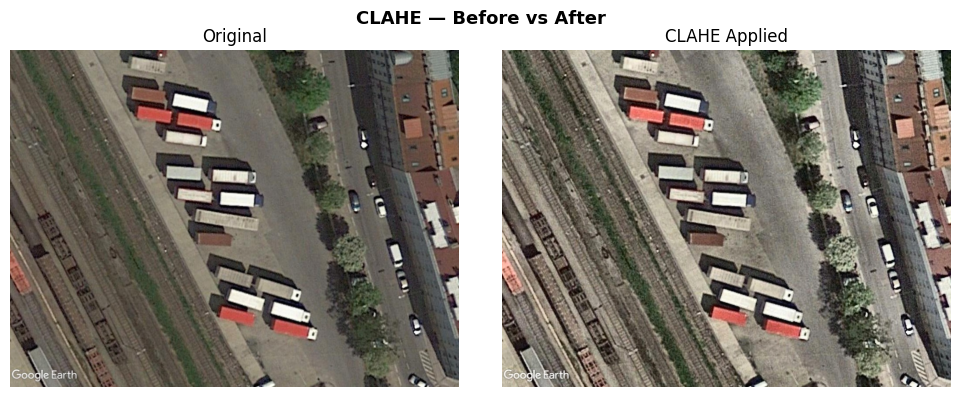

  Saved → clahe_compare.png


In [ ]:
sample  = list(Path(f"{DRIVE}/training/images").glob("*"))[0]
orig    = cv2.imread(str(sample))
clahe   = cv2.imread(str(Path(f"{PREP}/training/images") / sample.name))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("CLAHE — Before vs After", fontsize=13, fontweight="bold")
axes[0].imshow(cv2.cvtColor(orig,  cv2.COLOR_BGR2RGB)); axes[0].set_title("Original");      axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(clahe, cv2.COLOR_BGR2RGB)); axes[1].set_title("CLAHE Applied"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(f"{PREP}/clahe_compare.png", dpi=150); plt.show()
print("  Saved → clahe_compare.png")

**TILING**

In [ ]:
TILE    = 512
OVERLAP = 0.2
MIN_VIS = 0.3

def read_labels(p):
    if not Path(p).exists(): return []
    return [tuple([int(r[0])] + list(map(float, r[1:])))
            for line in Path(p).read_text().strip().splitlines()
            if len(r := line.split()) == 5]

def remap(cx, cy, bw, bh, tx, ty, W, H):
    x1, x2 = (cx - bw/2)*W, (cx + bw/2)*W
    y1, y2 = (cy - bh/2)*H, (cy + bh/2)*H
    ix1, ix2 = max(x1, tx), min(x2, tx + TILE)
    iy1, iy2 = max(y1, ty), min(y2, ty + TILE)
    if ix2 <= ix1 or iy2 <= iy1: return None
    if (ix2-ix1)*(iy2-iy1) / ((x2-x1)*(y2-y1) + 1e-6) < MIN_VIS: return None
    return (((ix1+ix2)/2 - tx)/TILE, ((iy1+iy2)/2 - ty)/TILE,
            (ix2-ix1)/TILE, (iy2-iy1)/TILE)

def tile_image(img, labels, stem, di, dl):
    H, W   = img.shape[:2]
    stride = int(TILE * (1 - OVERLAP))
    xs = sorted(set(list(range(0, W - TILE, stride)) + [max(0, W - TILE)]))
    ys = sorted(set(list(range(0, H - TILE, stride)) + [max(0, H - TILE)]))
    i = 0
    for ty in ys:
        for tx in xs:
            crop = np.zeros((TILE, TILE, 3), np.uint8)
            s = img[ty:ty+TILE, tx:tx+TILE]
            crop[:s.shape[0], :s.shape[1]] = s
            tlbls = []
            for (c, cx, cy, bw, bh) in labels:
                r = remap(cx, cy, bw, bh, tx, ty, W, H)
                if r: tlbls.append((c, *r))
            name = f"{stem}_t{i:03d}"
            cv2.imwrite(str(di / f"{name}.jpg"), crop, [cv2.IMWRITE_JPEG_QUALITY, 95])
            Path(dl / f"{name}.txt").write_text(
                '\n'.join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
                          for c, x, y, w, h in tlbls))
            i += 1

# Tile training and test — results go back into PREP/training and PREP/test
for split in ["training", "test"]:
    src_imgs  = Path(PREP)/split/'images'
    src_lbls  = Path(PREP)/split/'labels'
    tile_imgs = Path(PREP)/split/'tile_images'
    tile_lbls = Path(PREP)/split/'tile_labels'
    tile_imgs.mkdir(parents=True, exist_ok=True)
    tile_lbls.mkdir(parents=True, exist_ok=True)

    for f in tqdm(list(src_imgs.glob('*')), desc=f'Tiling {split}'):
        img = cv2.imread(str(f))
        if img is None: continue
        lbls = read_labels(src_lbls / f"{f.stem}.txt")
        tile_image(img, lbls, f.stem, tile_imgs, tile_lbls)

    shutil.rmtree(src_imgs); tile_imgs.rename(src_imgs)
    shutil.rmtree(src_lbls); tile_lbls.rename(src_lbls)
    print(f"  {split}: {len(list(src_imgs.glob('*.jpg')))} tiles")


Tiling training: 100%|██████████| 4000/4000 [13:41<00:00,  4.87it/s]


  training: 24000 tiles


Tiling test: 100%|██████████| 1000/1000 [03:38<00:00,  4.57it/s]


  test: 6000 tiles


**Split Training set to Train/Val**

In [ ]:
# TRAIN/VAL SPLIT — 3600 train / 400 val
random.seed(42)
src_imgs = Path(PREP)/'training'/'images'
src_lbls = Path(PREP)/'training'/'labels'

for d in ['train','val']:
    (Path(PREP)/d/'images').mkdir(parents=True, exist_ok=True)
    (Path(PREP)/d/'labels').mkdir(parents=True, exist_ok=True)

all_stems = [f.stem for f in src_imgs.glob('*.jpg')]
val_stems  = set(random.sample(all_stems, 400))
train_stems = set(all_stems) - val_stems

for stem in all_stems:
    split = 'val' if stem in val_stems else 'train'
    shutil.move(str(src_imgs/f"{stem}.jpg"), Path(PREP)/split/'images'/f"{stem}.jpg")
    lbl = src_lbls/f"{stem}.txt"
    if lbl.exists():
        shutil.move(str(lbl), Path(PREP)/split/'labels'/f"{stem}.txt")

print(f"  Train: {len(train_stems)} tiles")
print(f"  Val  : {len(val_stems)} tiles")
print(f"  Test : {len(list((Path(PREP)/'test'/'images').glob('*.jpg')))} tiles")

**Yaml file**

In [ ]:
yaml_path = f"{PREP}/simd.yaml"
with open(yaml_path, "w") as f:
    yaml.dump({
        "path" : PREP,
        "train": "train/images",
        "val"  : "val/images",
        "test" : "test/images",
        "nc"   : NUM_CLASSES,
        "names": CLASS_NAMES,
    }, f)
print(f"  Saved → {yaml_path}")

YAML CONFIG
  Saved → /content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/simd.yaml


**TRAIN YOLOv2 MODEL**

In [ ]:
print("TRAINING...")
model = YOLO("yolo12s.pt")
model.train(
    data      = yaml_path,
    epochs    = 100,
    imgsz     = 512,
    batch     = 16,
    optimizer = "AdamW",
    lr0       = 1e-3,
    cos_lr    = True,
    patience  = 30,
    mosaic    = 0.5,
    degrees   = 180,
    flipud    = 0.5,
    cache     = True,
    project   = f"{PREP}/runs",
    name      = "simd_yolov12",
    exist_ok  = True,
)

TRAINING...
WARNING ⚠️ model 'yolo12s.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/Object-detection-using-YOLOv12/Preprocessed/simd.yaml, degrees=180, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=Fals

**TRAINING CURVES**

In [ ]:
import pandas as pd
csv = Path(f"{PREP}/runs/simd_yolov12/results.csv")
df  = pd.read_csv(csv); df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("YOLOv12 — Training Results", fontsize=13, fontweight="bold")

for col, lbl, c in [("train/box_loss","Box","royalblue"),
                     ("train/cls_loss","Class","tomato"),
                     ("train/dfl_loss","DFL","seagreen")]:
    if col in df: axes[0].plot(df[col], label=lbl, color=c)
axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

for col, lbl, c in [("val/box_loss","Box","royalblue"),
                     ("val/cls_loss","Class","tomato")]:
    if col in df: axes[1].plot(df[col], label=lbl, color=c)
axes[1].set_title("Val Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

for col, lbl, c in [("metrics/mAP50(B)","mAP@0.5","darkorange"),
                     ("metrics/mAP50-95(B)","mAP@0.5:95","purple")]:
    if col in df: axes[2].plot(df[col], label=lbl, color=c)
axes[2].set_title("mAP"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PREP}/training_curves.png", dpi=150); plt.show()
print(f"  Saved → {PREP}/training_curves.png")

**Test**

In [ ]:
best  = f"{PREP}/runs/simd_yolov12/weights/best.pt"
model = YOLO(best)

test_imgs = list((Path(PREP)/'test'/'images').glob('*.jpg'))
results   = model.predict(
    source   = str(Path(PREP)/'test'/'images'),
    imgsz    = 512,
    conf     = 0.25,
    save     = True,
    project  = f"{PREP}/runs",
    name     = "simd_test",
    exist_ok = True,
    verbose  = False,
)

**Visualize Test Results**